<a href="https://colab.research.google.com/github/pradnyakawalkar/Session_assignment/blob/main/Session_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/content/diamonds.csv")
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df.head(10)

# Diamonds dataset is used for price prediction.
# It contains both numerical and categorical features.
# The target variable is price, which is continuous.
# This dataset is suitable for Regression.
# It is useful for data preprocessing and visualization.

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [5]:
missing = df.isnull().sum()

percentage = (missing/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values":missing,
    "Percentage":percentage
})

missing_df

# There are very few/no missing values.
# Missing values were handled using forward fill.
# Duplicate rows were checked.
# Duplicate records were removed.
# Dataset became clean for further analysis.

,Missing Values,Percentage
Unnamed: 0,0,0.0
carat,0,0.0
cut,0,0.0
color,0,0.0
clarity,0,0.0
depth,0,0.0
table,0,0.0
price,0,0.0
x,0,0.0
y,0,0.0


In [10]:

print("Minimum Price :", df["price"].min())

print("Maximum Price :", df["price"].max())

print("Mean Price :", df["price"].mean())

print("Median Price :", df["price"].median())

# Price varies from minimum to maximum over a wide range.
# Mean price is higher than the median, indicating some expensive diamonds.
# Carat values are mostly below 2.
# Most numerical columns have different scales.


Minimum Price : 326
Maximum Price : 18823
Mean Price : 3932.799721913237
Median Price : 2401.0


In [24]:
df.select_dtypes(include='object').columns

Index(['cut', 'color', 'clarity'], dtype='object')

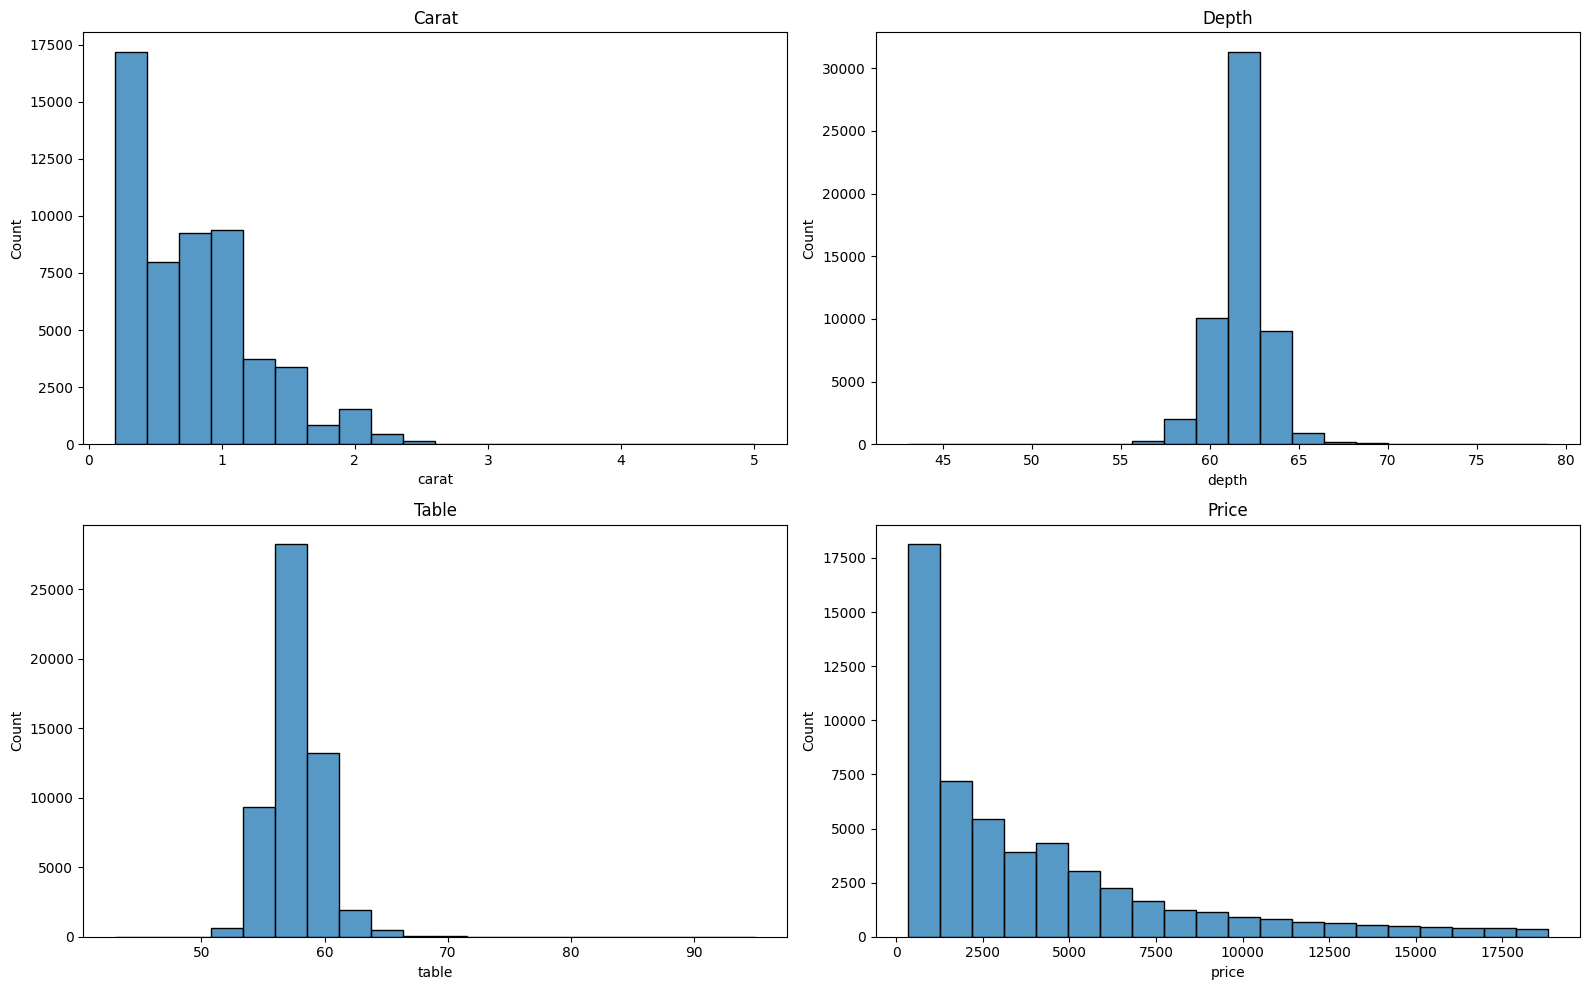

In [25]:

plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
sns.histplot(df['carat'], bins=20)
plt.title("Carat")

# Depth
plt.subplot(2,2,2)
sns.histplot(df['depth'], bins=20)
plt.title("Depth")

# Table
plt.subplot(2,2,3)
sns.histplot(df['table'], bins=20)
plt.title("Table")

# Price
plt.subplot(2,2,4)
sns.histplot(df['price'], bins=20)
plt.title("Price")

plt.tight_layout()
plt.show()


# Carat: Most diamonds have smaller carat values.
# Depth: Values are concentrated around the average, showing an almost normal distribution.
# Table: Most diamonds have table values between 55 and 60.
# Price: Distribution is right-skewed, with most diamonds having lower prices.



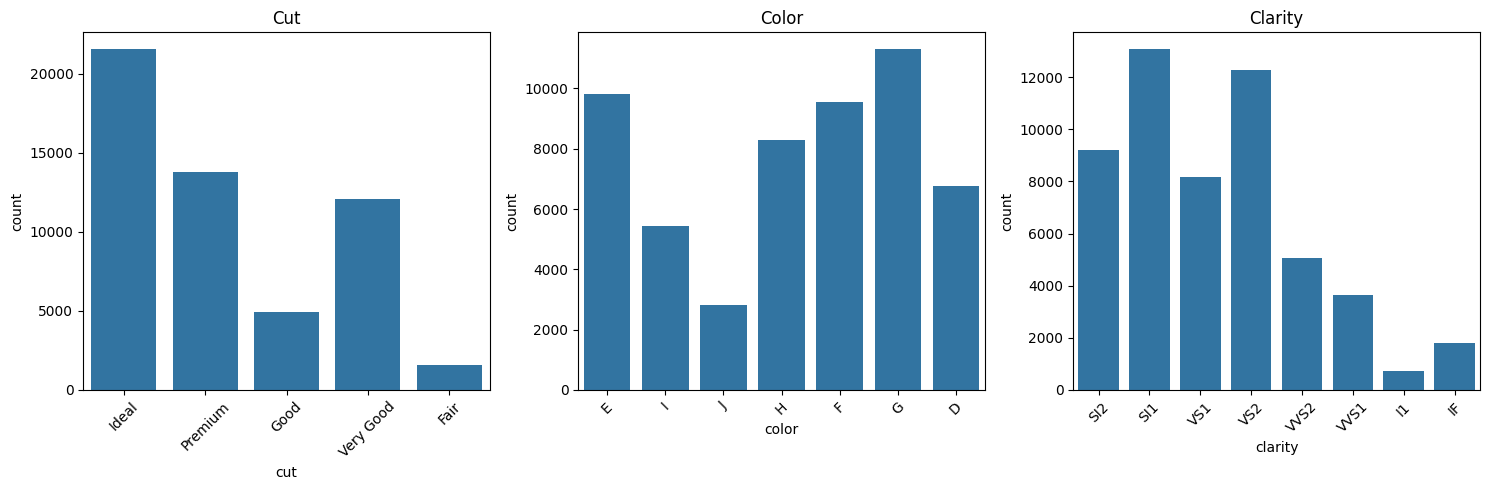

In [18]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.countplot(x='cut', data=df)
plt.xticks(rotation=45)
plt.title("Cut")

plt.subplot(1,3,2)
sns.countplot(x='color', data=df)
plt.xticks(rotation=45)
plt.title("Color")

plt.subplot(1,3,3)
sns.countplot(x='clarity', data=df)
plt.xticks(rotation=45)
plt.title("Clarity")

plt.tight_layout()
plt.show()


# Ideal cut diamonds are the most common.
# G color diamonds have the highest count.
# SI1 clarity diamonds appear most frequently.
# Some categories contain fewer diamonds.

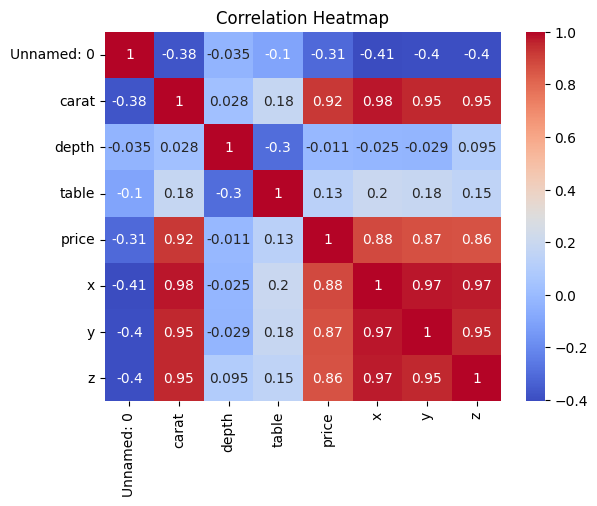

In [21]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Carat has the strongest positive correlation with price. As the carat weight increases, the diamond price also increases.
# x, y, and z (diamond dimensions) also show a strong positive correlation with price because larger diamonds are generally more expensive.
# Depth has a very weak correlation with price, indicating that it has little effect on the diamond's price.
# Table has a weak correlation with price, so it is not a major factor in determining the price.

# Carat is the most important feature for predicting the target variable (price).
# x, y, and z are strongly correlated with each other because they represent the physical dimensions of the diamond.
# Depth and table have relatively weak relationships with price compared to carat.
# There is no strong negative correlation among the numeric features.
# Features with high positive correlation, such as carat, x, y, and z, are useful for building a regression model to predict diamond prices.

In [26]:
X = df.drop("price", axis=1)

y = df["price"]

print("Independent Features (X)")
print(X.head())

print("\nDependent Feature (y)")
print(y.head())

# X contains all input features.
# y (price) is the continuous target variable that we want to predict.

Independent Features (X)
   Unnamed: 0  carat      cut color clarity  depth  table     x     y     z
0           1   0.23    Ideal     E     SI2   61.5   55.0  3.95  3.98  2.43
1           2   0.21  Premium     E     SI1   59.8   61.0  3.89  3.84  2.31
2           3   0.23     Good     E     VS1   56.9   65.0  4.05  4.07  2.31
3           4   0.29  Premium     I     VS2   62.4   58.0  4.20  4.23  2.63
4           5   0.31     Good     J     SI2   63.3   58.0  4.34  4.35  2.75

Dependent Feature (y)
0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64


In [27]:
from pandas.core.reshape.encoding import get_dummies
print("Before Encoding")

print(df[['cut','color']].head())
encoded_df = pd.get_dummies(df, columns=['cut','color','clarity'])

print("After Encoding")
encoded_df.head()

# for this we use get_dummies() function.
# Categorical columns were converted into numeric columns.
# One-Hot Encoding avoids assigning incorrect numerical order to categories.
# Encoded data is suitable for machine learning algorithms.

Before Encoding
       cut color
0    Ideal     E
1  Premium     E
2     Good     E
3  Premium     I
4     Good     J
After Encoding


,Unnamed: 0,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,1,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,...,False,False,False,False,True,False,False,False,False,False
2,3,0.23,56.9,65.0,327,4.05,4.07,2.31,False,True,...,False,False,False,False,False,False,True,False,False,False
3,4,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,...,True,False,False,False,False,False,False,True,False,False
4,5,0.31,63.3,58.0,335,4.34,4.35,2.75,False,True,...,False,True,False,False,False,True,False,False,False,False


In [28]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# One-Hot Encoding
encoded_df = pd.get_dummies(df, columns=['cut', 'color', 'clarity'], drop_first=True)

# Independent Features (X)
X = encoded_df.drop('price', axis=1)

# Target Variable (y)
y = encoded_df['price']

# Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("First 5 Rows of Scaled Features:")
X_scaled.head()


# StandardScaler transformed all independent features to a common scale.
# After scaling, the features have approximately mean = 0 and standard deviation = 1.
# Feature scaling prevents features with larger values from dominating the model.
# Scaled data improves the performance of many machine learning algorithms.

First 5 Rows of Scaled Features:


,Unnamed: 0,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,-1.732019,-1.198168,-0.174092,-1.099672,-1.587837,-1.536196,-1.571129,-0.316312,1.225928,-0.586085,...,-0.42657,-0.334294,-0.234343,-0.185268,-0.565361,2.206098,-0.422524,-0.542295,-0.269603,-0.321954
1,-1.731954,-1.240361,-1.360738,1.585529,-1.641325,-1.658774,-1.741175,-0.316312,-0.815708,1.706238,...,-0.42657,-0.334294,-0.234343,-0.185268,1.768781,-0.453289,-0.422524,-0.542295,-0.269603,-0.321954
2,-1.731890,-1.198168,-3.385019,3.375663,-1.498691,-1.457395,-1.741175,3.161440,-0.815708,-0.586085,...,-0.42657,-0.334294,-0.234343,-0.185268,-0.565361,-0.453289,2.366727,-0.542295,-0.269603,-0.321954
3,-1.731826,-1.071587,0.454133,0.242928,-1.364971,-1.317305,-1.287720,-0.316312,-0.815708,1.706238,...,-0.42657,2.991381,-0.234343,-0.185268,-0.565361,-0.453289,-0.422524,1.844015,-0.269603,-0.321954
4,-1.731762,-1.029394,1.082358,0.242928,-1.240167,-1.212238,-1.117674,3.161440,-0.815708,-0.586085,...,-0.42657,-0.334294,4.267248,-0.185268,-0.565361,2.206098,-0.422524,-0.542295,-0.269603,-0.321954
